## Bu projede ne öğreneceksin?
Bu projede A/B testinin, oyunda yapılan değişikliğin kullanıcı daranışı üzerindeki etkisini değerlendirmek için nasıl kullanılacağını öğreneceksiniz.

Bu proje sayesinde:
- A/B test mantığını gerçek bir veri seti üzerinde uygulamayı
- Veri seti üzerinde Keşifsel Veri Analizi (EDA) yapmayı
- Kontrol ve test gruplarını karşılaştırmayı
- Hipotez ve testleri kurmayı ve yorumlamayı
- Normallik ve varyans varsayımlarını kontrol etmeyi
- Parametrik ve non-parametrik testleri uygulamayı
- Oran testi(proporstions z-test) yapmayı
- Güven aralıkları hesaplamayı
- İstatiksel sonuçlara göre karar vermeyi
öğreneceksiniz.

# Introduction
`A/B Testing`, bir ürün veya sistem üzerinde değişiklik yapıldığında kullanıcının davranışı üzerindeki etkiyi ölçmek için kullanılan en yaygın istatiksel yöntemlerdendir. Bu yöntem sayesinde, iki farklı versiyonu karşılaştırır ve hangi değişikliğin daha iyi performans gösterdiğini istatiksel olarak belirleyebiliriz.

Bu projede, Cookie Cats isminde ki mobil oyuna ait A/B test veri seti analiz edilecektir. Oyuncular rastgele ikisi farklı versiyona atanmıştır.

- gate_30 -> kontrol grubu
- gate_40 -> test grubu

Amaç, oyunda kapının yerinin değiştirilmesinin oyuncu davranışı üzerinde istatiksel olarak anlamlı bir etkinin olup olmadığını belirlemektir.

Bu proje kapsamında:
* Veri seti incelenecek
* Kontrol ve test grupları oluşturulacak
* Oyuncu davranış metrikleri karşılaştırılacak
* Hipotez testleri uygulanacak
* Oran testi yapılacak
* Güven aralıkları hesaplanacak
* Sonuçlar istatiksel olarak yorumlanacak

Bu çalışma, A/B testing yöntemi kullanılarak istatistiksel analizler aracılığıyla veri temelli karar verme sürecinin nasıl gerçekleştirilebileceğini göstermeyi amaçlamaktadır.

In [2]:
!pip install statsmodels

# Dataset Information
Bu veri seti, Cookie Cats adlı mobil oyunda yapılan bir A/B testinin sonuçlarını içermektedir. 
Oyuncular rastgele iki farklı versiyona atanmıştır ve yapılan değişikliğin oyuncu davranışı üzerindeki etkisi ölçülmek istenmiştir.

Oyunda oyuncuların ilerleyebilmesi için belirli seviyelerde bir kapı (gate) bulunmaktadır. 
Bu A/B testinde kapının konumu değiştirilmiştir:

gate_30 → Kapı 30. seviyede (kontrol grubu)  
gate_40 → Kapı 40. seviyede (test grubu)

Amaç, kapının yerinin değiştirilmesinin oyuncuların oyuna devam etme davranışı 
üzerinde istatistiksel olarak anlamlı bir fark oluşturup oluşturmadığını incelemektir.

Veri setinde aşağıdaki değişkenler bulunmaktadır:

`userid` → oyuncu kimliği  
`version` → oyuncunun bulunduğu grup (gate_30 / gate_40)  
`sum_gamerounds` → oyuncunun oynadığı toplam oyun sayısı  
`retention_1` → oyuncu 1 gün sonra oyuna geri geldi mi  
`retention_7` → oyuncu 7 gün sonra oyuna geri geldi mi

Bu proje kapsamında, A/B testing yöntemi kullanılarak iki grup arasındaki farklar 
istatistiksel testler yardımıyla analiz edilecektir.

# Data Loading

In [3]:
######################################################
# Libraries
######################################################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.stats.api as sms

from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu
from statsmodels.stats.proportion import proportions_ztest
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats/cookie_cats.csv


In [4]:
df = pd.read_csv("/kaggle/input/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats/cookie_cats.csv")

df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


# Data Overview

In [5]:
df.shape

(90189, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


Veri seti 90.189 gözlem ve 5 değişkenden oluşmaktadır. 
Değişken tipleri incelendiğinde, userid ve sum_gamerounds değişkenlerinin sayısal, 
version değişkeninin kategorik, retention_1 ve retention_7 değişkenlerinin ise boolean yapıda olduğu görülmektedir.

Veri setinin bellek kullanımı oldukça düşüktür ve analiz için uygun bir yapıdadır.

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
userid,90189.0,4.998412e+06,2.883286e+06,116.0,2512230.0,4995815.0,7496452.0,9999861.0
sum_gamerounds,90189.0,5.187246e+01,1.950509e+02,0.0,5.0,16.0,51.0,49854.0


Betimsel istatistikler incelendiğinde, oyuncuların oynadığı toplam oyun sayısının (sum_gamerounds) 
ortalamasının yaklaşık 51.87 olduğu görülmektedir. Ancak medyan değerin 16 olması ve maksimum değerin 
49.854'e kadar çıkması, bu değişkende ciddi sağa çarpıklık ve aykırı gözlemler olabileceğini göstermektedir.

Bu nedenle, ilerleyen aşamalarda normallik varsayımı dikkatle kontrol edilmelidir.

## Missing Values

In [8]:
df.isnull().sum()

userid            0
version           0
sum_gamerounds    0
retention_1       0
retention_7       0
dtype: int64

Veri setinde eksik gözlem bulunmamaktadır. 
Bu durum, analiz sürecinde ek bir eksik veri işlemi yapılmasına gerek olmadığını göstermektedir.

# Group Distribution

In [9]:
df["version"].value_counts()
df["version"].value_counts(normalize=True)

version
gate_40    0.504374
gate_30    0.495626
Name: proportion, dtype: float64

A/B testinin doğru sonuç verebilmesi için kontrol ve test gruplarının birbirine yakın büyüklükte olması gerekir.

Version değişkeni incelendiğinde, kullanıcıların yaklaşık %50'sinin gate_30 grubunda,
%50'sinin ise gate_40 grubunda olduğu görülmektedir.

Bu durum, kullanıcıların gruplara rastgele ve dengeli şekilde atandığını göstermektedir.

In [10]:
#---------------------------------------------
# Group Comparison
#--------------------------------------------
df.groupby("version").agg({
    "sum_gamerounds": ["mean", "median"],
    "retention_1": "mean",
    "retention_7": "mean"
})

sum_gamerounds        retention_1 retention_7
                  mean median        mean        mean
version                                              
gate_30      52.456264   17.0    0.448188    0.190201
gate_40      51.298776   16.0    0.442283    0.182000

Gruplar arasındaki ortalamalar incelendiğinde, gate_30 ve gate_40 versiyonları arasında
sum_gamerounds, retention_1 ve retention_7 değişkenlerinde küçük farklar olduğu görülmektedir.

Ancak bu farkların istatistiksel olarak anlamlı olup olmadığını anlayabilmek için
hipotez testleri uygulanmalıdır.

# Exploratory Data Analysis (EDA)

In [11]:
# Theme and palette
sns.set_theme(style="whitegrid", context="notebook")
palette = ["#5DA5DA", "#F17CB0"]

In [12]:
# -----------------------------
# 1. Group-wise summary table
# -----------------------------
group_summary = df.groupby("version").agg({
    "userid": "count",
    "sum_gamerounds": ["mean", "median", "std", "min", "max"],
    "retention_1": "mean",
    "retention_7": "mean"
})

print("Group Summary")
display(group_summary)

Group Summary


userid sum_gamerounds                               retention_1  \
         count           mean median         std min    max        mean   
version                                                                   
gate_30  44700      52.456264   17.0  256.716423   0  49854    0.448188   
gate_40  45489      51.298776   16.0  103.294416   0   2640    0.442283   

        retention_7  
               mean  
version              
gate_30    0.190201  
gate_40    0.182000

/tmp/ipykernel_55/2979162732.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="version", palette=palette)


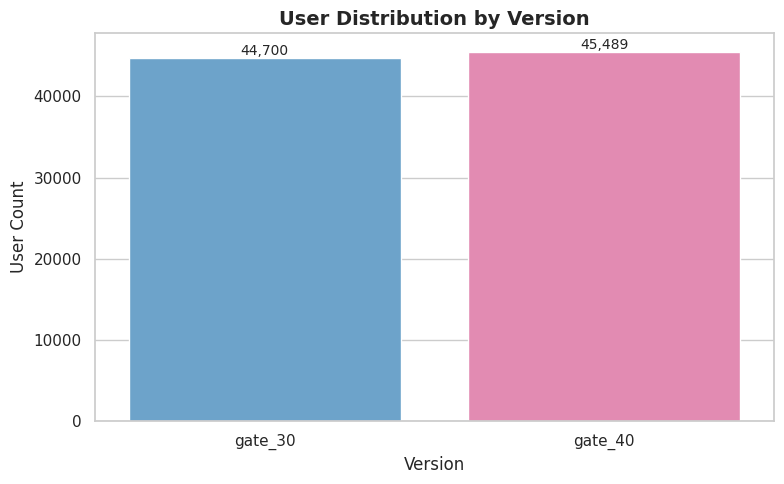

In [13]:
# -----------------------------
# 2. Group size visualization
# -----------------------------
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x="version", palette=palette)

plt.title("User Distribution by Version", fontsize=14, fontweight="bold")
plt.xlabel("Version")
plt.ylabel("User Count")

for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

Grafik incelendiğinde kullanıcıların iki farklı versiyon arasında neredeyse eşit şekilde dağıldığı görülmektedir. 
gate_30 versiyonunda yaklaşık 44.700 kullanıcı bulunurken, gate_40 versiyonunda yaklaşık 45.489 kullanıcı bulunmaktadır.

Bu durum, A/B testinin sağlıklı bir şekilde gerçekleştirildiğini ve kullanıcıların kontrol ve test gruplarına 
dengeli şekilde dağıtıldığını göstermektedir. Dengeli grup büyüklükleri, yapılacak istatistiksel testlerin 
daha güvenilir sonuçlar vermesine yardımcı olur.

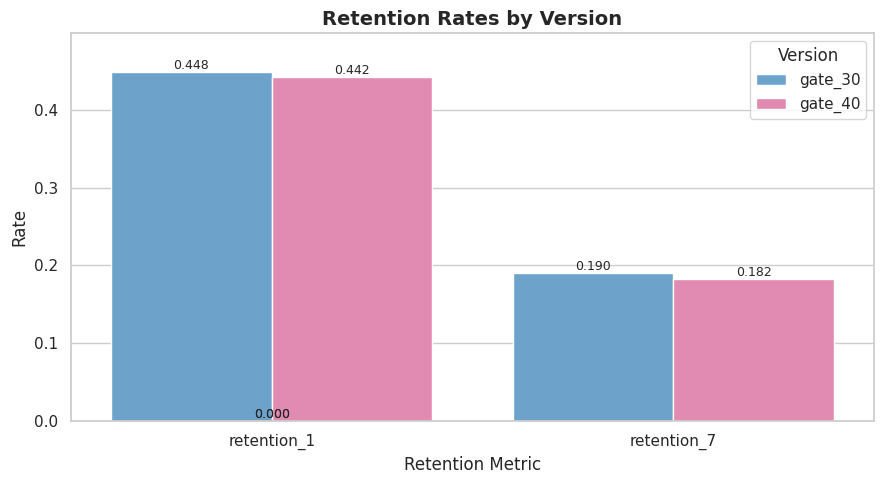

In [14]:
# -----------------------------
# 3. Retention rates by group
# -----------------------------
retention_summary = df.groupby("version")[["retention_1", "retention_7"]].mean().reset_index()
retention_long = retention_summary.melt(id_vars="version",
                                        var_name="metric",
                                        value_name="rate")

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=retention_long, x="metric", y="rate", hue="version", palette=palette)

plt.title("Retention Rates by Version", fontsize=14, fontweight="bold")
plt.xlabel("Retention Metric")
plt.ylabel("Rate")
plt.ylim(0, retention_long["rate"].max() + 0.05)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.3f}",
                (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom", fontsize=9)

plt.legend(title="Version")
plt.tight_layout()
plt.show()

Grafik incelendiğinde, gate_30 ve gate_40 versiyonları arasında retention oranlarında küçük farklar olduğu görülmektedir.

1 günlük retention oranı gate_30 grubunda yaklaşık %44.8 iken, gate_40 grubunda yaklaşık %44.2 olarak hesaplanmıştır. 
Benzer şekilde, 7 günlük retention oranı gate_30 grubunda yaklaşık %19.0, gate_40 grubunda ise yaklaşık %18.2 seviyesindedir.

İlk bakışta gate_30 versiyonunun her iki metrikte de biraz daha yüksek performans gösterdiği görülmektedir. 
Ancak bu farkların rastlantısal mı yoksa istatistiksel olarak anlamlı mı olduğunu belirlemek için 
hipotez testleri uygulanması gerekmektedir.

Bu nedenle, bir sonraki aşamada A/B testing yaklaşımı kullanılarak iki grup arasındaki fark 
istatistiksel testler ile analiz edilecektir

/tmp/ipykernel_55/1014174882.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=game_rounds_mean, x="version", y="sum_gamerounds", palette=palette)


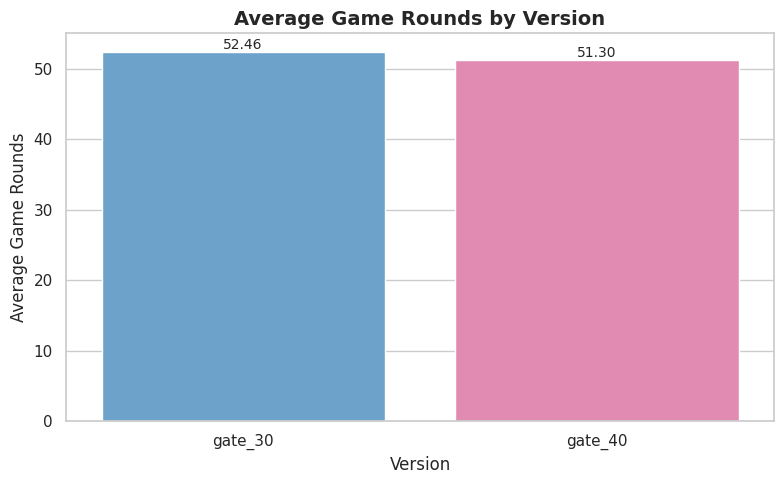

In [15]:
# -----------------------------
# 4. Mean game rounds by group
# -----------------------------
game_rounds_mean = df.groupby("version")["sum_gamerounds"].mean().reset_index()

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=game_rounds_mean, x="version", y="sum_gamerounds", palette=palette)

plt.title("Average Game Rounds by Version", fontsize=14, fontweight="bold")
plt.xlabel("Version")
plt.ylabel("Average Game Rounds")

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.2f}",
                (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

Ortalama oyun sayıları incelendiğinde gate_30 versiyonundaki kullanıcıların ortalama 52.46 oyun,
gate_40 versiyonundaki kullanıcıların ise ortalama 51.30 oyun oynadığı görülmektedir.

İlk bakışta gate_30 grubunun biraz daha yüksek ortalama oyun sayısına sahip olduğu dikkat çekmektedir. 
Ancak ortalama değerler tek başına yeterli değildir. sum_gamerounds değişkeninin dağılımı 
incelenmeden bu farkın anlamlı olup olmadığına karar verilemez.

Özellikle oyun sayısı gibi davranışsal metriklerde aykırı değerler bulunabileceğinden,
bir sonraki adımda dağılım ve aykırı gözlemler kontrol edilecektir.

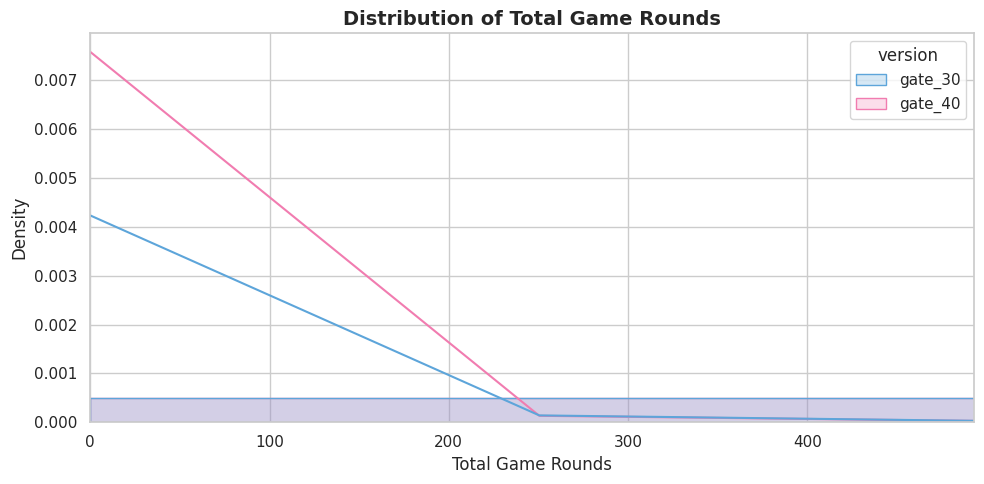

In [16]:
# -----------------------------
# 5. Distribution of game rounds
# -----------------------------
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="sum_gamerounds", hue="version",
             bins=50, kde=True, palette=palette, element="step", stat="density")

plt.title("Distribution of Total Game Rounds", fontsize=14, fontweight="bold")
plt.xlabel("Total Game Rounds")
plt.ylabel("Density")
plt.xlim(0, df["sum_gamerounds"].quantile(0.99))  # extreme outliersi baskılamak için
plt.tight_layout()
plt.show()

Dağılım grafiği incelendiğinde, sum_gamerounds değişkeninin her iki grup için de normal dağılıma uymadığı görülmektedir. 
Dağılımın sağa çarpık olduğu ve özellikle yüksek oyun sayısına sahip kullanıcıların bulunduğu dikkat çekmektedir.

Bu durum, veri setinde aykırı değerler (outliers) bulunduğunu ve ortalama değerlerin bu gözlemlerden 
etkilenebileceğini göstermektedir. Bu nedenle parametrik testlerin uygulanabilmesi için gerekli olan 
normallik varsayımı ayrıca kontrol edilmelidir.

Bir sonraki aşamada, gruplar için normallik varsayımı Shapiro-Wilk testi ile incelenecek ve 
sonuca göre parametrik veya non-parametrik test tercih edilecektir.

/tmp/ipykernel_55/974321775.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="version", y="sum_gamerounds", palette=palette)


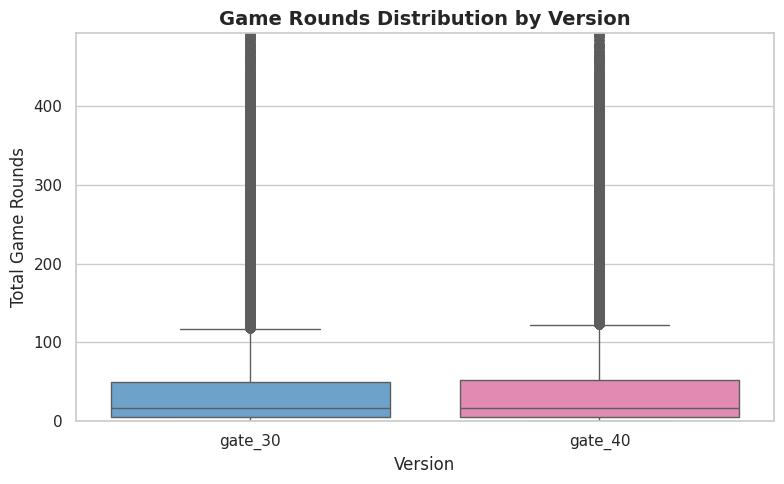

In [17]:
# -----------------------------
# 6. Boxplot for outlier check
# -----------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="version", y="sum_gamerounds", palette=palette)

plt.title("Game Rounds Distribution by Version", fontsize=14, fontweight="bold")
plt.xlabel("Version")
plt.ylabel("Total Game Rounds")
plt.ylim(0, df["sum_gamerounds"].quantile(0.99))  # okunabilirlik için

plt.tight_layout()
plt.show()

Boxplot grafiği incelendiğinde, her iki grup için de sum_gamerounds değişkeninde çok sayıda aykırı gözlem bulunduğu görülmektedir. 
Dağılımın büyük kısmı düşük oyun sayılarında yoğunlaşırken, bazı kullanıcıların çok yüksek sayıda oyun oynadığı dikkat çekmektedir.

Bu durum, ortalama değerlerin aykırı gözlemlerden etkilenebileceğini ve dağılımın normal olmadığını göstermektedir. 
Bu nedenle, parametrik testlerin uygulanabilmesi için gerekli olan normallik varsayımı ayrıca kontrol edilmelidir.

Bir sonraki aşamada, gruplar için normallik varsayımı Shapiro-Wilk testi ile incelenecek ve 
sonuca göre parametrik veya non-parametrik test tercih edilecektir.

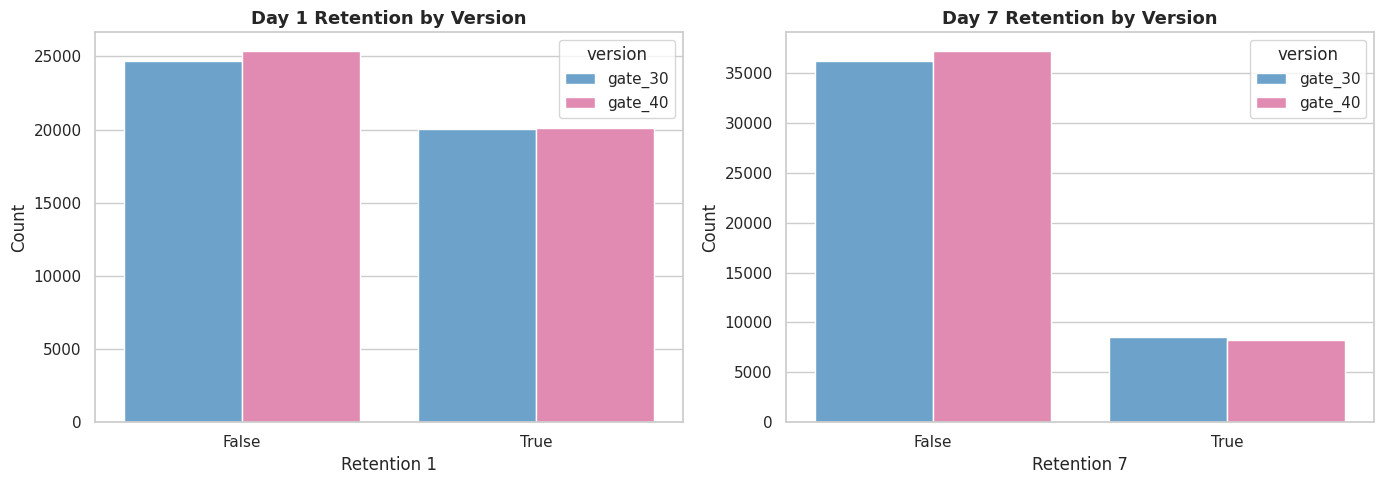

In [18]:
# -----------------------------
# 7. Retention counts
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x="retention_1", hue="version", palette=palette, ax=axes[0])
axes[0].set_title("Day 1 Retention by Version", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Retention 1")
axes[0].set_ylabel("Count")

sns.countplot(data=df, x="retention_7", hue="version", palette=palette, ax=axes[1])
axes[1].set_title("Day 7 Retention by Version", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Retention 7")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

1 günlük ve 7 günlük retention değerleri incelendiğinde, gate_30 ve gate_40 versiyonları arasında çok büyük bir fark olmadığı görülmektedir.

Her iki grafikte de kullanıcıların çoğunluğunun oyuna geri dönmediği, ancak küçük bir kısmının 1. gün ve 7. gün tekrar oyuna giriş yaptığı dikkat çekmektedir.

Gate_30 grubunda retention oranlarının gate_40 grubuna göre biraz daha yüksek olduğu görülse de, bu farkın istatistiksel olarak anlamlı olup olmadığını sadece grafiklere bakarak söylemek mümkün değildir.

Bu nedenle, iki grup arasındaki retention oranlarını karşılaştırmak için  iki örneklem oran testi (proportions z-test) uygulanacaktır.

In [19]:
# -----------------------------
# 8. Quantile check for outliers
# -----------------------------
quantiles = df["sum_gamerounds"].quantile([0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
print("Quantiles of sum_gamerounds")
display(quantiles)

Quantiles of sum_gamerounds


0.01      0.0
0.05      1.0
0.25      5.0
0.50     16.0
0.75     51.0
0.95    221.0
0.99    493.0
Name: sum_gamerounds, dtype: float64

Quantile değerleri incelendiğinde, sum_gamerounds değişkeninin dağılımının oldukça geniş olduğu görülmektedir. 
Median değerin 16 olduğu, ancak %99'luk dilimde bu değerin 493'e kadar çıktığı dikkat çekmektedir.

Bu durum veri setinde çok sayıda aykırı gözlem bulunduğunu ve dağılımın sağa çarpık olduğunu göstermektedir. 
Özellikle üst quantile değerlerinin çok yüksek olması, ortalama değerlerin güvenilirliğini azaltabilir.

Bu nedenle, hipotez testine geçmeden önce normallik varsayımı kontrol edilecek ve 
sonuca göre parametrik veya non-parametrik test tercih edilecektir.

# Problem Definition & Hypothesis
Bu çalışmada, Cookie Cats mobil oyununda yapılan A/B testinin sonuçları analiz edilecektir. 
Oyuncular rastgele iki farklı versiyona atanmıştır:

gate_30 → Kapı 30. seviyede  
gate_40 → Kapı 40. seviyede  

Amaç, kapının yerinin değiştirilmesinin oyuncuların oyuna devam etme davranışı üzerinde 
istatistiksel olarak anlamlı bir etkisi olup olmadığını belirlemektir.

Bu analizde aşağıdaki metrikler incelenecektir:

- sum_gamerounds → oyuncunun oynadığı toplam oyun sayısı  
- retention_1 → oyuncunun 1 gün sonra oyuna geri dönüp dönmediği  
- retention_7 → oyuncunun 7 gün sonra oyuna geri dönüp dönmediği  

A/B testing kapsamında iki grup arasındaki farkın anlamlı olup olmadığını belirlemek için 
hipotez testleri uygulanacaktır.

**Hipotezler:**

`H0`: gate_30 ve gate_40 grupları arasında oyuncu davranışı açısından istatistiksel olarak anlamlı bir fark yoktur.

`H1`: gate_30 ve gate_40 grupları arasında oyuncu davranışı açısından istatistiksel olarak anlamlı bir fark vardır.

Hipotez testine geçmeden önce, parametrik testlerin uygulanabilmesi için gerekli olan 
normallik ve varyans homojenliği varsayımları kontrol edilecektir. 
Varsayımlar sağlanmazsa non-parametrik test kullanılacaktır.

# Assumption Checks
Hipotez testine geçmeden önce parametrik testlerin uygulanabilmesi için gerekli olan varsayımları kontrol etmek gerekir. 
Bu çalışmada iki grup karşılaştırılacağı için öncelikle normallik varsayımı ve varyans homojenliği varsayımı incelenecektir.

> Normallik varsayımı için **Shapiro-Wilk testi**, varyans homojenliği için ise Levene testi kullanılacaktır.Eğer varsayımlar sağlanırsa bağımsız iki örneklem **t-testi**, varsayımlar sağlanmazsa **non-parametrik test olan Mann-Whitney U testi** uygulanacaktır.

## Normality Test (Shapiro-Wilk)

In [20]:
gate30 = df.loc[df["version"] == "gate_30", "sum_gamerounds"]
gate40 = df.loc[df["version"] == "gate_40", "sum_gamerounds"]

test_stat, pvalue = shapiro(gate30.sample(5000))
print("gate_30 p-value:", pvalue)

test_stat, pvalue = shapiro(gate40.sample(5000))
print("gate_40 p-value:", pvalue)

gate_30 p-value: 1.1334643076023539e-81
gate_40 p-value: 5.651901921501949e-81


Shapiro-Wilk testi sonuçlarına göre her iki grup için de p-value değeri 0.05'ten küçük bulunmuştur. 
Bu durum, sum_gamerounds değişkeninin normal dağılıma uymadığını göstermektedir.

Veri setinde daha önce yapılan EDA analizinde de dağılımın sağa çarpık olduğu ve çok sayıda aykırı gözlem bulunduğu görülmüştü. 
Shapiro testi de bu durumu doğrulamaktadır.

Bu nedenle parametrik testlerin uygulanabilmesi için gerekli olan normallik varsayımı sağlanmamaktadır.
Bir sonraki adımda varyans homojenliği kontrol edilecek ve test seçimi buna göre yapılacaktır.

## Variance Homogeneity Test (Levene)

In [21]:
test_stat, pvalue = levene(gate30, gate40)
print("Levene p-value:", pvalue)

Levene p-value: 0.46694516772623273


Levene testi sonucunda p-value değeri 0.05'ten büyük bulunmuştur. 
Bu sonuç, iki grup arasında varyansların homojen olduğunu göstermektedir.

Ancak bir önceki aşamada yapılan Shapiro-Wilk testi sonucunda normallik varsayımının sağlanmadığı görülmüştür. 
Parametrik testlerin uygulanabilmesi için hem normallik hem de varyans homojenliği varsayımlarının sağlanması gerekir.

Bu nedenle, varyanslar homojen olsa bile normallik varsayımı sağlanmadığı için 
bağımsız iki örneklem t-testi yerine non-parametrik test olan Mann-Whitney U testi kullanılacaktır.

## Test Selection
Normallik ve varyans homojenliği varsayımları kontrol edilmiştir.

Shapiro-Wilk testi sonucunda verinin normal dağılmadığı görülmüştür. 
Levene testi sonucunda varyansların homojen olduğu görülse de, parametrik testlerin uygulanabilmesi için 
normallik varsayımının da sağlanması gerekmektedir.

Bu nedenle, iki grup karşılaştırılırken parametrik test olan bağımsız iki örneklem t-testi yerine 
non-parametrik test olan Mann-Whitney U testi kullanılacaktır.

# A/B Testing for Game Rounds
Bu aşamada, gate_30 ve gate_40 grupları arasında oyuncuların oynadığı toplam oyun sayısı 
(sum_gamerounds) açısından istatistiksel olarak anlamlı bir fark olup olmadığı test edilecektir.

Normallik varsayımı sağlanmadığı için parametrik test yerine 
non-parametrik Mann-Whitney U testi uygulanacaktır.

In [22]:
test_stat, pvalue = mannwhitneyu(gate30, gate40)

print("Test Stat:", test_stat)
print("p-value:", pvalue)

Test Stat: 1024331250.5
p-value: 0.05020880772044255


Mann-Whitney U testi sonucunda p-value değerinin 0.05'ten büyük olduğu görülmektedir (p ≈ 0.0502). 
Bu sonuç, gate_30 ve gate_40 grupları arasında oynanan toplam oyun sayısı açısından 
istatistiksel olarak anlamlı bir fark olmadığını göstermektedir.

Ortalama oyun sayısı gate_30 grubunda biraz daha yüksek görünse de, 
bu fark istatistiksel olarak anlamlı değildir.

# A/B Testing for Retention (Proportion Test)
Bu aşamada gate_30 ve gate_40 grupları arasında oyuncuların oyuna geri dönme oranları 
(retention) açısından anlamlı bir fark olup olmadığı test edilecektir.

Retention değişkenleri boolean olduğu için iki grup arasındaki oran farkını test etmek amacıyla 
iki örneklem oran testi (proportions z-test) uygulanacaktır.

## `retention_1` Test:

In [23]:
# gate_30
gate30_ret1 = df.loc[df["version"] == "gate_30", "retention_1"]

# gate_40
gate40_ret1 = df.loc[df["version"] == "gate_40", "retention_1"]


success = [
    gate30_ret1.sum(),
    gate40_ret1.sum()
]

nobs = [
    gate30_ret1.shape[0],
    gate40_ret1.shape[0]
]


test_stat, pvalue = proportions_ztest(count=success, nobs=nobs)

print("Test Stat:", test_stat)
print("p-value:", pvalue)

Test Stat: 1.7840862247974725
p-value: 0.07440965529691913


1 günlük retention için yapılan proportions z-test sonucunda p-value değerinin 
0.05'ten büyük olduğu görülmektedir (p ≈ 0.0744). 

Bu sonuç, gate_30 ve gate_40 grupları arasında retention_1 açısından 
istatistiksel olarak anlamlı bir fark olmadığını göstermektedir.

Her ne kadar gate_30 grubunun retention oranı biraz daha yüksek görünse de, 
bu fark istatistiksel olarak anlamlı değildir.

## `retention_7` Test:

In [24]:
gate30_ret7 = df.loc[df["version"] == "gate_30", "retention_7"]
gate40_ret7 = df.loc[df["version"] == "gate_40", "retention_7"]

success = [
    gate30_ret7.sum(),
    gate40_ret7.sum()
]

nobs = [
    gate30_ret7.shape[0],
    gate40_ret7.shape[0]
]

test_stat, pvalue = proportions_ztest(count=success, nobs=nobs)

print("Test Stat:", test_stat)
print("p-value:", pvalue)

Test Stat: 3.164358912748191
p-value: 0.001554249975614329


7 günlük retention için yapılan proportions z-test sonucunda p-value değeri 0.05'ten küçük bulunmuştur (p ≈ 0.0015). 
Bu sonuç, gate_30 ve gate_40 grupları arasında retention_7 açısından istatistiksel olarak anlamlı bir fark olduğunu göstermektedir.

Retention oranları incelendiğinde gate_30 grubunun gate_40 grubuna göre daha yüksek performans gösterdiği görülmektedir. 
Bu durum, kapının 30. seviyede olmasının oyuncuların oyuna daha uzun süre devam etmesine katkı sağladığını göstermektedir.

Sonuç olarak, A/B testine göre gate_30 versiyonu oyuncu bağlılığı açısından daha başarılı görünmektedir.

# Confidence Interval
Bu aşamada, gate_30 ve gate_40 grupları için ortalama oyun sayısının güven aralıkları hesaplanacaktır. 
Güven aralığı, ortalama değerin hangi aralıkta olabileceğini tahmin etmek için kullanılır ve 
gruplar arasındaki farkı yorumlamaya yardımcı olur.

In [26]:
gate30 = df.loc[df["version"] == "gate_30", "sum_gamerounds"]
gate40 = df.loc[df["version"] == "gate_40", "sum_gamerounds"]

ci_gate30 = sms.DescrStatsW(gate30).tconfint_mean()
ci_gate40 = sms.DescrStatsW(gate40).tconfint_mean()

ci_df = pd.DataFrame({
    "Group": ["gate_30", "gate_40"],
    "CI Lower": [ci_gate30[0], ci_gate40[0]],
    "CI Upper": [ci_gate30[1], ci_gate40[1]]
})

ci_df.round(2)

,Group,CI Lower,CI Upper
0,gate_30,50.08,54.84
1,gate_40,50.35,52.25


Güven aralığı sonuçları incelendiğinde gate_30 grubu için ortalama oyun sayısının 
50.08 ile 54.84 arasında, gate_40 grubu için ise 50.35 ile 52.25 arasında olduğu görülmektedir.

İki grubun güven aralıklarının birbiriyle örtüştüğü dikkat çekmektedir. 
Bu durum, ortalamalar arasında gözlenen farkın istatistiksel olarak anlamlı olmadığını göstermektedir.

Bu sonuç, daha önce yapılan Mann-Whitney U testi ile de uyumludur ve 
kapının 30. seviyede veya 40. seviyede olmasının oyuncuların oynadığı toplam oyun sayısı 
üzerinde belirgin bir etkisi olmadığını desteklemektedir.

------------------------------------------------------------

# Final Conclusion
Bu çalışmada, Cookie Cats oyununda yapılan A/B testinin sonuçları detaylı şekilde analiz edilmiştir. 
Amaç, oyuncuların ilerlemesini engelleyen kapının 30. seviyede (gate_30) veya 40. seviyede (gate_40) 
olmasının oyuncu davranışı üzerinde anlamlı bir etkisi olup olmadığını belirlemektir.

Analiz sürecinde oyuncuların oynadığı toplam oyun sayısı (sum_gamerounds), 
1 günlük retention (retention_1) ve 7 günlük retention (retention_7) metrikleri incelenmiştir. 
Öncelikle veri keşif analizi yapılmış, dağılım yapısı ve aykırı değerler kontrol edilmiştir. 
Dağılımın normal olmadığı görüldüğü için parametrik test yerine non-parametrik test tercih edilmiştir.

Toplam oyun sayısı için yapılan Mann-Whitney U testi sonucunda, gate_30 ve gate_40 grupları arasında 
istatistiksel olarak anlamlı bir fark bulunmamıştır. Güven aralığı sonuçları da iki grubun ortalamalarının 
birbirine oldukça yakın olduğunu göstermektedir.

1 günlük retention için yapılan oran testinde de iki grup arasında anlamlı bir fark bulunmamıştır. 
Bu sonuç, kapının yerinin kısa vadeli oyuncu davranışı üzerinde belirgin bir etkisi olmadığını göstermektedir.

Ancak 7 günlük retention için yapılan proportions z-test sonucunda p-value değerinin 0.05'ten küçük olduğu görülmüş 
ve iki grup arasında istatistiksel olarak anlamlı bir fark olduğu tespit edilmiştir. 
Retention oranları incelendiğinde gate_30 grubunun gate_40 grubuna göre daha yüksek performans gösterdiği görülmektedir.

Bu sonuçlar birlikte değerlendirildiğinde, kapının 30. seviyede olmasının oyuncuların oyuna daha uzun süre bağlı kalmasına 
katkı sağladığı söylenebilir. Özellikle uzun vadeli oyuncu bağlılığı açısından gate_30 versiyonu daha başarılı görünmektedir.

Sonuç olarak, A/B test bulgularına göre oyuncu deneyimini ve retention oranlarını iyileştirmek için 
gate_30 versiyonunun kullanılmasının daha uygun olacağı değerlendirilmektedir.

# Business Interpretation
Yapılan A/B test sonuçları, kapının 30. seviyede veya 40. seviyede olmasının oyuncu davranışı 
üzerindeki etkisini anlamak için analiz edilmiştir.

Toplam oyun sayısı ve 1 günlük retention açısından iki grup arasında anlamlı bir fark bulunmamıştır. 
Ancak 7 günlük retention sonuçları incelendiğinde gate_30 grubunun daha yüksek performans gösterdiği 
ve bu farkın istatistiksel olarak anlamlı olduğu görülmüştür.

Bu durum, kapının daha ileri bir seviyeye alınmasının oyuncuların oyuna bağlılığını artırmadığını, 
hatta uzun vadede oyuncuların oyundan kopmasına neden olabileceğini göstermektedir.

Bu nedenle ürün geliştirme açısından değerlendirildiğinde, kapının 30. seviyede kalmasının 
oyuncu deneyimi ve uzun vadeli bağlılık açısından daha uygun olduğu söylenebilir.

# Limitations
Bu analiz yalnızca mevcut veri seti üzerinden yapılmıştır ve oyuncuların davranışlarını etkileyebilecek 
diğer faktörler veri setinde yer almamaktadır.

Örneğin oyuncuların yaşı, oyun oynama süresi, oyun içi satın alma davranışı veya oyuncu seviyesine göre 
farklılıklar bu analizde dikkate alınmamıştır.

Ayrıca veri setinde bulunan değişkenler sınırlı olduğu için oyuncu davranışını etkileyebilecek 
tüm faktörleri değerlendirmek mümkün olmamıştır.

Bu nedenle sonuçlar yorumlanırken analiz kapsamının sınırlı olduğu göz önünde bulundurulmalıdır.